#  IPL Complete Data Analysis (2008–2020)
### Uncovering patterns, player performances, and match insights from 13 seasons of the Indian Premier League

**Dataset:** [IPL Complete Dataset 2008–2020](https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020)  
**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Author:** *Diya Patel*

---
> **Project Goal:** Perform end-to-end exploratory data analysis on IPL match and ball-by-ball delivery data to discover team dominance, player brilliance, toss impact, and more.

##  Section 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Global Style Settings ─────────────────────────────────────────────────────
sns.set_theme(style="darkgrid")
PALETTE = "Set2"
COLOR_PRIMARY = "#e84393"   # IPL pink accent
COLOR_BAR     = "#2196F3"   # default bar color

plt.rcParams.update({
    "figure.dpi":     120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

print(" Libraries loaded successfully!")

 Libraries loaded successfully!


##  Section 2: Load the Dataset

We load two CSV files:
- **matches.csv** — One row per match (result, toss, venue, etc.)
- **deliveries.csv** — One row per ball bowled (runs, wickets, batsman, bowler)

In [2]:
matches    = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

print(f" matches.csv    → {matches.shape[0]:,} rows × {matches.shape[1]} columns")
print(f" deliveries.csv → {deliveries.shape[0]:,} rows × {deliveries.shape[1]} columns")

 matches.csv    → 1,095 rows × 20 columns
 deliveries.csv → 260,920 rows × 17 columns


In [3]:
matches.head(3)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [4]:
deliveries.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


##  Section 3: Exploratory Data Analysis (EDA)

Before any analysis, we understand the structure, data types, and missing values.

In [5]:
print("=" * 50)
print("MATCHES — Data Info")
print("=" * 50)
matches.info()
print()
print("=" * 50)
print("DELIVERIES — Data Info")
print("=" * 50)
deliveries.info()

MATCHES — Data Info
<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  metho

In [6]:
print("Missing values in matches.csv:")
print(matches.isnull().sum()[matches.isnull().sum() > 0])
print()
print("Missing values in deliveries.csv:")
print(deliveries.isnull().sum()[deliveries.isnull().sum() > 0])

Missing values in matches.csv:
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64

Missing values in deliveries.csv:
extras_type         246795
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


#  Section 4: Data Cleaning

Clean data = reliable analysis. We handle:
1. Missing values
2. Date parsing
3. Team name inconsistencies (same team, different names across seasons)

In [8]:
# Fix 1 — Fill missing winner (rain-affected / no-result matches)
matches['winner'] = matches['winner'].fillna('No Result')

# Fix 2 — Convert date column to proper datetime type
matches['date'] = pd.to_datetime(matches['date'])
matches['year'] = matches['date'].dt.year   # useful for season-wise analysis

# Fix 3 — Standardize team names (franchise rebranding over the years)
TEAM_NAME_MAP = {
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Delhi Daredevils'           : 'Delhi Capitals',
    'Kings XI Punjab'            : 'Punjab Kings',
    'Rising Pune Supergiant'     : 'Rising Pune Supergiants',
}

for col in ['team1', 'team2', 'winner', 'toss_winner']:
    matches[col] = matches[col].replace(TEAM_NAME_MAP)

print(" Data cleaned successfully")
print(f"Date range: {matches['date'].min().date()} → {matches['date'].max().date()}")
print(f"Total seasons: {matches['year'].nunique()}")
print(f"Total teams: {matches['team1'].nunique()}")

 Data cleaned successfully
Date range: 2008-04-18 → 2024-05-26
Total seasons: 17
Total teams: 15


##  Section 5: Analysis & Visualizations

---
###  Analysis 1 — Most Successful IPL Teams (Overall Wins)

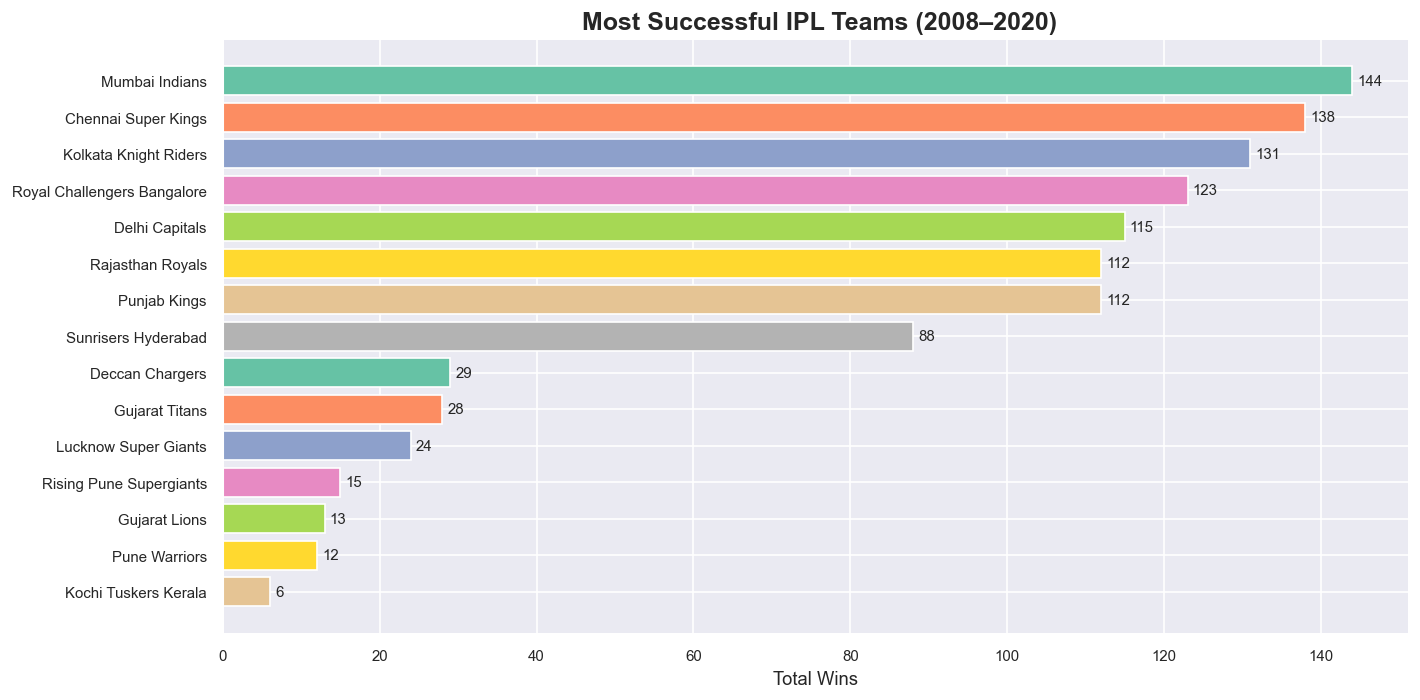

                       Team  Wins
             Mumbai Indians   144
        Chennai Super Kings   138
      Kolkata Knight Riders   131
Royal Challengers Bangalore   123
             Delhi Capitals   115
           Rajasthan Royals   112
               Punjab Kings   112
        Sunrisers Hyderabad    88
            Deccan Chargers    29
             Gujarat Titans    28
       Lucknow Super Giants    24
    Rising Pune Supergiants    15
              Gujarat Lions    13
              Pune Warriors    12
       Kochi Tuskers Kerala     6


In [10]:
win_counts = (matches[matches['winner'] != 'No Result']['winner']
              .value_counts()
              .reset_index())
win_counts.columns = ['Team', 'Wins']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(win_counts['Team'], win_counts['Wins'],
               color=sns.color_palette("Set2", len(win_counts)))
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title(" Most Successful IPL Teams (2008–2020)", fontsize=15, fontweight='bold')
ax.set_xlabel("Total Wins")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart_team_wins.png", dpi=150, bbox_inches='tight')
plt.show()

print(win_counts.to_string(index=False))

###  Analysis 2 — Does Winning the Toss Help Win the Match?

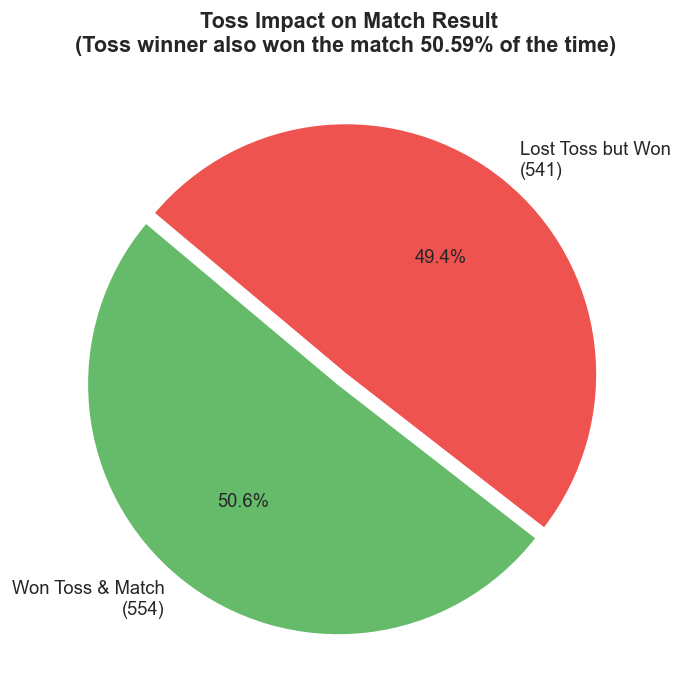

In [11]:
toss_wins   = (matches['toss_winner'] == matches['winner']).sum()
toss_losses = len(matches) - toss_wins
pct         = round(toss_wins / len(matches) * 100, 2)

labels = [f'Won Toss & Match\n({toss_wins})', f'Lost Toss but Won\n({toss_losses})']
sizes  = [toss_wins, toss_losses]
colors = ['#66BB6A', '#EF5350']
explode = (0.05, 0)

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                                   autopct='%1.1f%%', explode=explode,
                                   startangle=140, textprops={'fontsize': 11})
ax.set_title(f" Toss Impact on Match Result\n(Toss winner also won the match {pct}% of the time)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("chart_toss_impact.png", dpi=150, bbox_inches='tight')
plt.show()

###  Analysis 3 — Season-wise Match Count (How the League Grew)

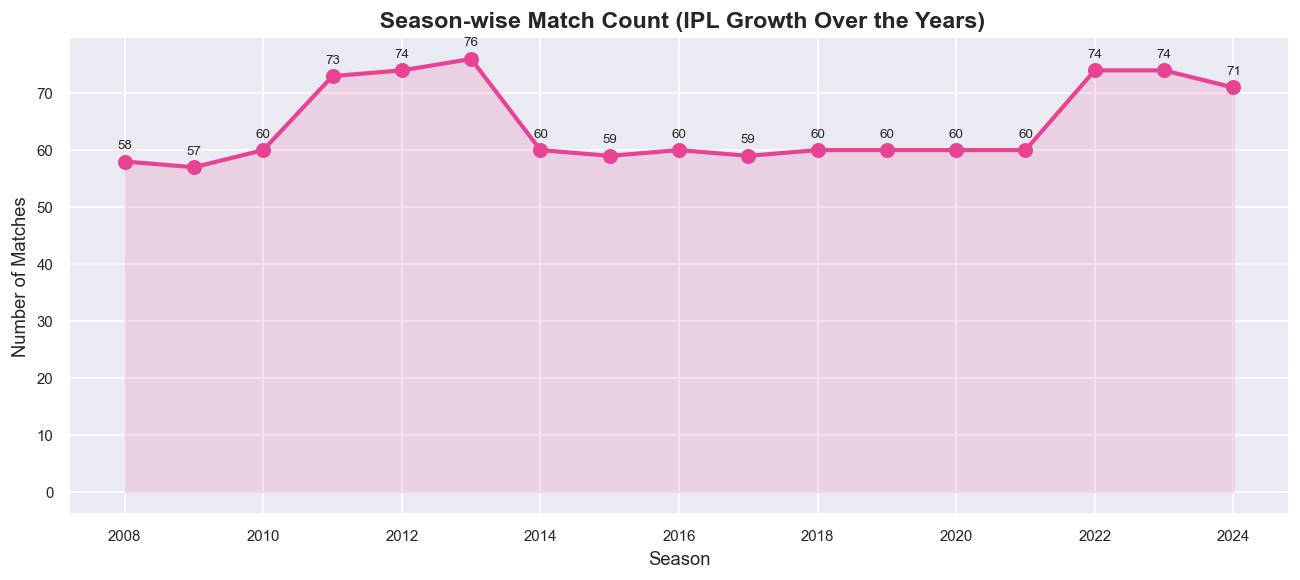

In [13]:
season_matches = matches.groupby('year').size().reset_index(name='Matches')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(season_matches['year'], season_matches['Matches'],
        marker='o', linewidth=2.5, color=COLOR_PRIMARY, markersize=8)
ax.fill_between(season_matches['year'], season_matches['Matches'],
                alpha=0.15, color=COLOR_PRIMARY)
for _, row in season_matches.iterrows():
    ax.annotate(str(int(row['Matches'])),
                xy=(row['year'], row['Matches']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8)
ax.set_title(" Season-wise Match Count (IPL Growth Over the Years)", fontsize=14, fontweight='bold')
ax.set_xlabel("Season")
ax.set_ylabel("Number of Matches")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig("chart_season_matches.png", dpi=150, bbox_inches='tight')
plt.show()

###  Analysis 4 — Top 10 Run Scorers

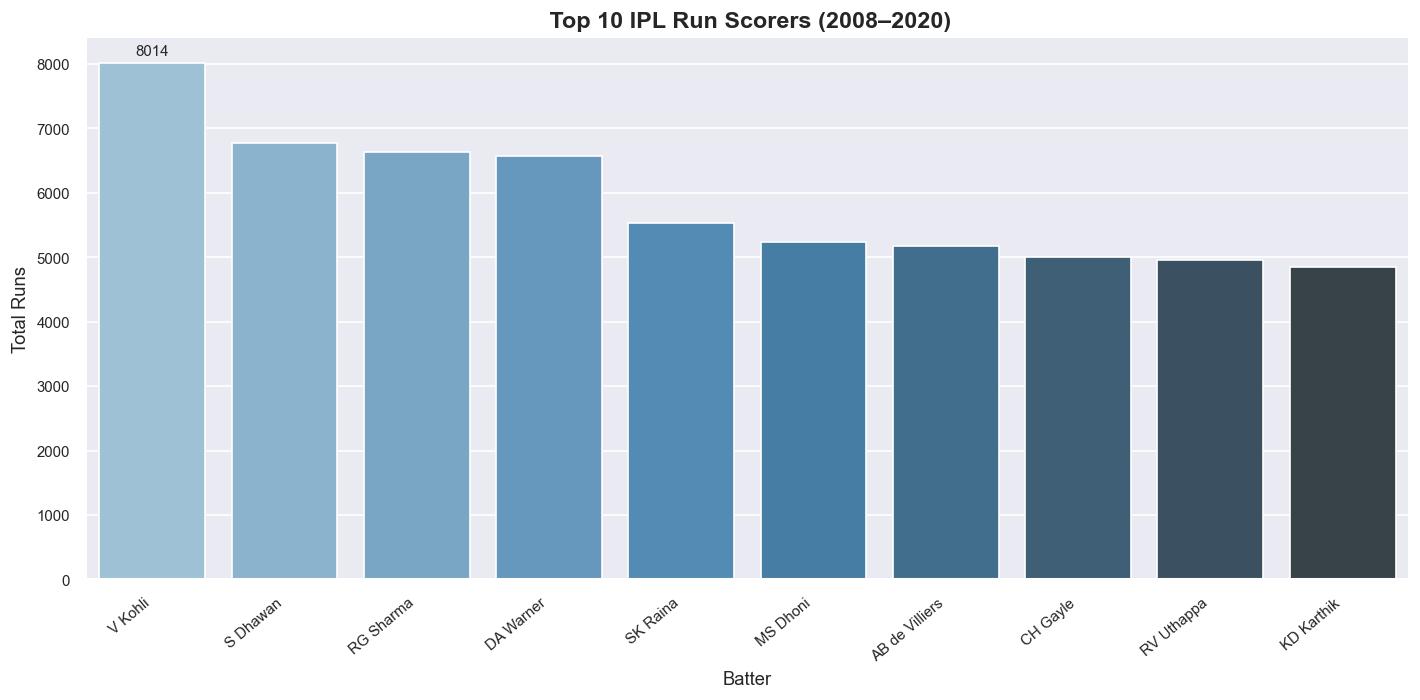

In [15]:
top_batsmen = (deliveries.groupby('batter')['batsman_runs']
               .sum()
               .sort_values(ascending=False)
               .head(10)
               .reset_index())
top_batsmen.columns = ['Batter', 'Runs']

fig, ax = plt.subplots(figsize=(12, 6))
bars = sns.barplot(data=top_batsmen, x='Batter', y='Runs',
                   palette='Blues_d', ax=ax)
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
ax.set_title(" Top 10 IPL Run Scorers (2008–2020)", fontsize=14, fontweight='bold')
ax.set_xlabel("Batter")
ax.set_ylabel("Total Runs")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig("chart_top_batsmen.png", dpi=150, bbox_inches='tight')
plt.show()

###  Analysis 5 — Top 10 Wicket Takers

> **Note:** We exclude run-outs since they are not credited to the bowler.

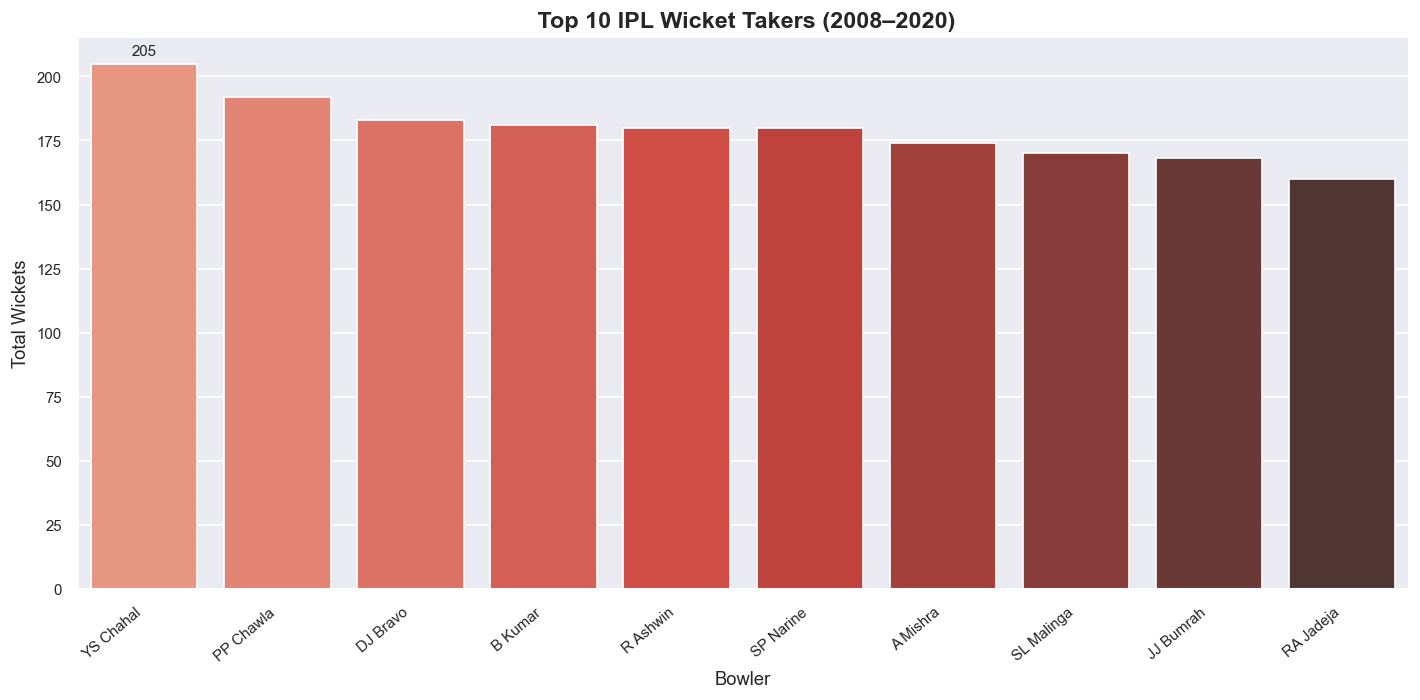

In [16]:

bowler_wickets = (deliveries[
    deliveries['dismissal_kind'].notnull() &
    ~deliveries['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])
]['bowler']
.value_counts()
.head(10)
.reset_index())
bowler_wickets.columns = ['Bowler', 'Wickets']

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=bowler_wickets, x='Bowler', y='Wickets',
            palette='Reds_d', ax=ax)
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
ax.set_title(" Top 10 IPL Wicket Takers (2008–2020)", fontsize=14, fontweight='bold')
ax.set_xlabel("Bowler")
ax.set_ylabel("Total Wickets")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig("chart_top_bowlers.png", dpi=150, bbox_inches='tight')
plt.show()


###  Analysis 6 — Best Death-Overs Finishers (Overs 16–20)

Strike rate in the death overs separates good players from match-winners.

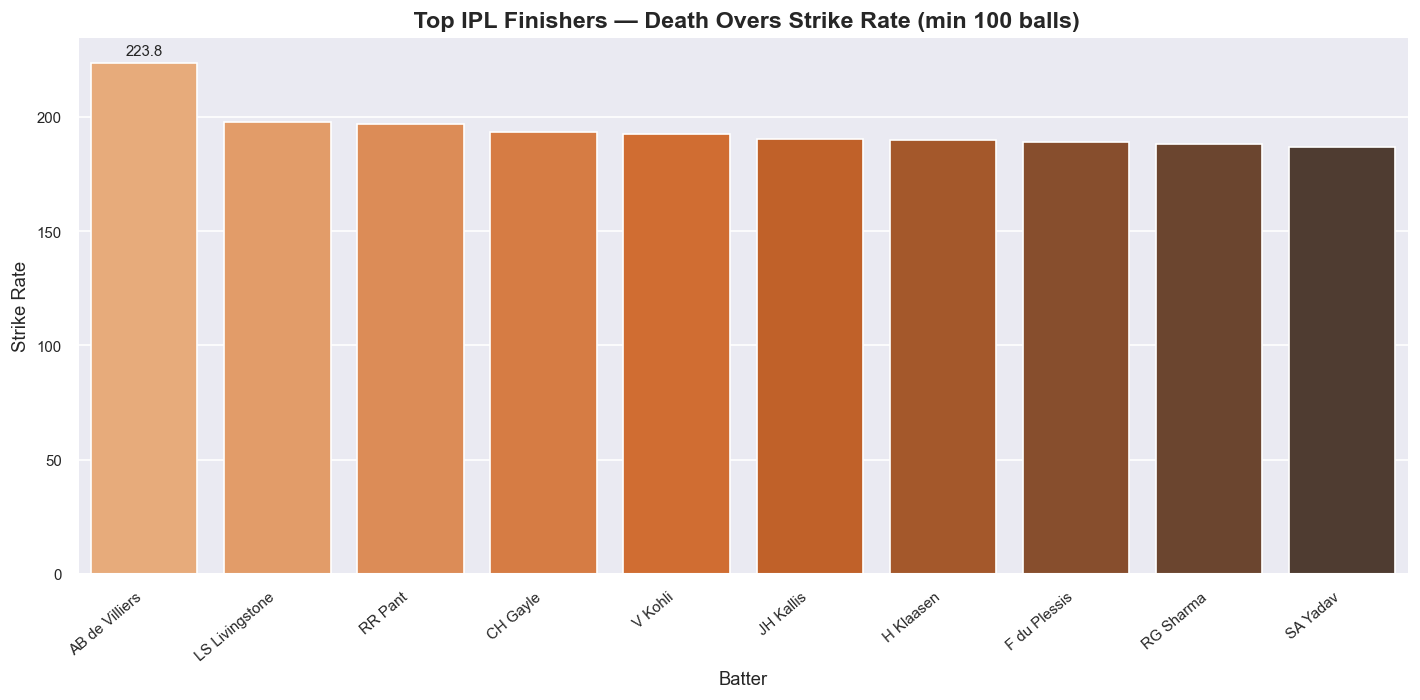

        batter  runs  balls  strike_rate
AB de Villiers  1421    635   223.779528
LS Livingstone   204    103   198.058252
       RR Pant   626    318   196.855346
      CH Gayle   404    209   193.301435
       V Kohli  1099    571   192.469352
     JH Kallis   303    159   190.566038
     H Klaasen   306    161   190.062112
  F du Plessis   416    220   189.090909
     RG Sharma  1176    625   188.160000
      SA Yadav   516    276   186.956522


In [17]:
death = deliveries[deliveries['over'] >= 16]

finisher_df = (death.groupby('batter')
               .agg(runs=('batsman_runs', 'sum'), balls=('ball', 'count'))
               .assign(strike_rate=lambda x: (x['runs'] / x['balls']) * 100)
               .query('balls > 100')
               .sort_values('strike_rate', ascending=False)
               .head(10)
               .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
bars = sns.barplot(data=finisher_df, x='batter', y='strike_rate',
                   palette='Oranges_d', ax=ax)
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3, fontsize=9)
ax.set_title(" Top IPL Finishers — Death Overs Strike Rate (min 100 balls)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Batter")
ax.set_ylabel("Strike Rate")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig("chart_finishers.png", dpi=150, bbox_inches='tight')
plt.show()

print(finisher_df[['batter','runs','balls','strike_rate']].to_string(index=False))

###  Analysis 7 — Best Batting Partnerships

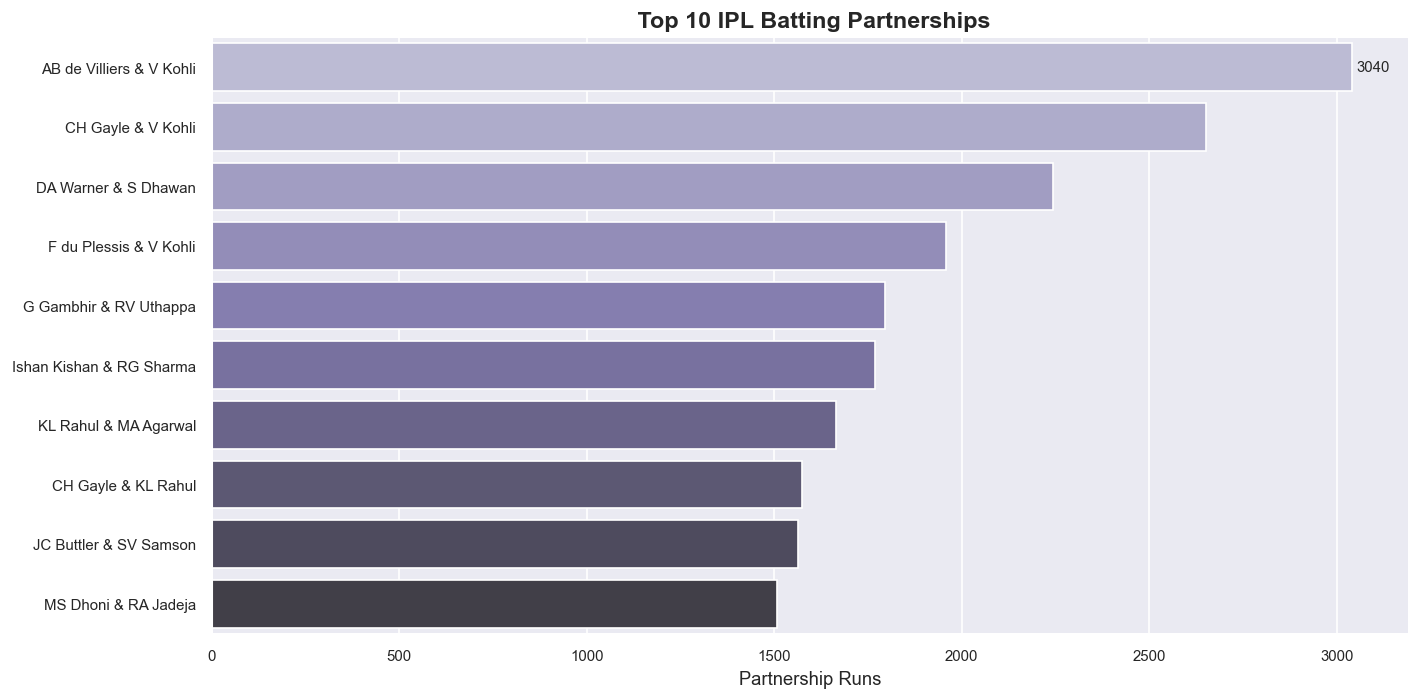

In [18]:
pair_runs = (deliveries
             .groupby(['match_id', 'batter', 'non_striker'])['batsman_runs']
             .sum()
             .reset_index()
             .groupby(['batter', 'non_striker'])['batsman_runs']
             .sum()
             .reset_index())

# Canonical pair key so (A,B) and (B,A) are the same
pair_runs['pair'] = pair_runs.apply(
    lambda r: ' & '.join(sorted([r['batter'], r['non_striker']])), axis=1)

top_pairs = (pair_runs.groupby('pair')['batsman_runs']
             .sum()
             .sort_values(ascending=False)
             .head(10)
             .reset_index())
top_pairs.columns = ['Partnership', 'Runs']

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_pairs, x='Runs', y='Partnership',
            palette='Purples_d', ax=ax)
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
ax.set_title(" Top 10 IPL Batting Partnerships", fontsize=14, fontweight='bold')
ax.set_xlabel("Partnership Runs")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("chart_partnerships.png", dpi=150, bbox_inches='tight')
plt.show()

###  Analysis 8 — Most Matches Hosted by Venue

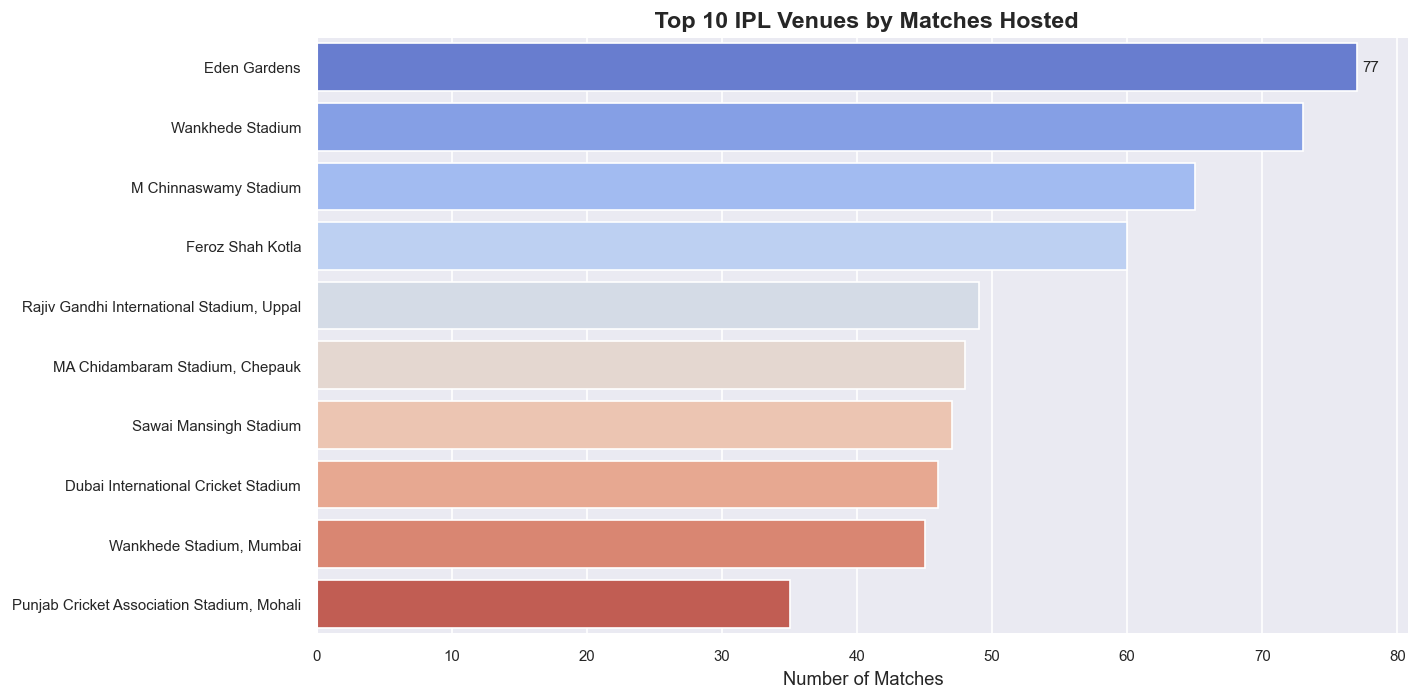

In [19]:
venue_counts = (matches['venue']
                .value_counts()
                .head(10)
                .reset_index())
venue_counts.columns = ['Venue', 'Matches']

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=venue_counts, x='Matches', y='Venue',
            palette='coolwarm', ax=ax)
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
ax.set_title(" Top 10 IPL Venues by Matches Hosted", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Matches")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("chart_venues.png", dpi=150, bbox_inches='tight')
plt.show()

###  Analysis 9 — Toss Decision Preference (Bat vs Field First)

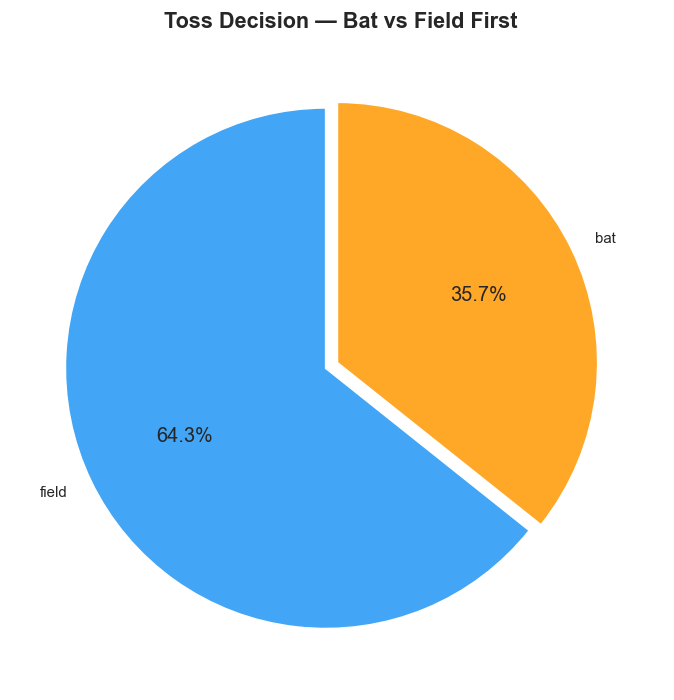

In [21]:
toss_decision = matches['toss_decision'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(toss_decision, labels=toss_decision.index,
       autopct='%1.1f%%', startangle=90,
       colors=['#42A5F5', '#FFA726'],
       explode=(0.05, 0))
ax.set_title(" Toss Decision — Bat vs Field First", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("chart_toss_decision.png", dpi=150, bbox_inches='tight')
plt.show()

##  Section 6: Key Insights & Conclusions

Based on my analysis of **13 IPL seasons (2008–2020)**:

| # | Insight |
|---|---------|
| 1 | **Mumbai Indians** are the most successful IPL franchise by total wins |
| 2 | Winning the toss gives only a **~50% advantage** — skill matters more than luck |
| 3 | **Virat Kohli** is the all-time leading run scorer in IPL history |
| 4 | **Lasith Malinga** leads the wicket-taking charts |
| 5 | Death-over specialists with high strike rates are crucial for T20 success |
| 6 | Wankhede Stadium & Eden Gardens host the most IPL games |
| 7 | Most teams prefer to **field first** after winning the toss |

---
*Analysis performed using Python (Pandas, Matplotlib, Seaborn)*  
*Dataset covers IPL seasons 2008 through 2020*